# Sentiment and Future Return Analysis

This notebook evaluates whether the current offline LLM sentiment labels have observable relationships with future returns. It uses already-processed local SQLite tables only; it does not call Groq, FastAPI, or the frontend.

The analysis is descriptive and exploratory. It is not investment advice.


In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = PROJECT_ROOT / "backend" / "data" / "twstock_sentiment.db"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.unicode_minus"] = False

RETURN_COLUMNS = ["future_return_1d", "future_return_3d", "future_return_5d"]
SENTIMENT_ORDER = ["negative", "neutral", "positive"]


## Load Data

Read the local analysis tables from SQLite. The merged `analysis_df` is the main row-level dataset used below.


In [2]:
with sqlite3.connect(DB_PATH) as conn:
    aligned = pd.read_sql_query("SELECT * FROM aligned_news_returns", conn)
    daily = pd.read_sql_query("SELECT * FROM daily_sentiment", conn)
    llm = pd.read_sql_query("SELECT * FROM llm_news_analysis", conn)
    raw = pd.read_sql_query("SELECT id AS news_id, title, published_at, source, url FROM raw_news", conn)

analysis_df = (
    aligned
    .merge(llm[["news_id", "status", "sentiment", "confidence", "target", "reason", "model_name"]], on="news_id", how="left", suffixes=("", "_llm"))
    .merge(raw, on="news_id", how="left")
)
analysis_df["trading_date"] = pd.to_datetime(analysis_df["trading_date"], errors="coerce")
analysis_df["published_at"] = pd.to_datetime(analysis_df["published_at"], errors="coerce")

print(f"DB path: {DB_PATH}")
print(f"aligned rows: {len(aligned):,}")
print(f"daily rows: {len(daily):,}")
print(f"llm rows: {len(llm):,}")
analysis_df.head()


DB path: C:\python_data_analysis_final\backend\data\twstock_sentiment.db
aligned rows: 304
daily rows: 46
llm rows: 426


,news_id,trading_date,target,news_type,sentiment_score,future_return_1d,future_return_3d,future_return_5d,status,sentiment,confidence,target_llm,reason,model_name,title,published_at,source,url
0,1,2026-05-18,2330,stock,-0.75,-0.015625,-0.004464,NaN,success,negative,0.75,2330,規則型 fallback：依公司、市場、產業與情緒關鍵字判斷，正式報告需人工複核。,rules-fallback,法國財長稱，如有必要G7再釋油儲，歐洲經濟放緩但未陷入衰退,2026-05-18 07:07:10+00:00,Yahoo Stock RSS,https://tw.stock.yahoo.com/news/%E6%B3%95%E5%9...
1,2,2026-05-18,2330,stock,0.75,-0.015625,-0.004464,NaN,success,positive,0.75,2330,規則型 fallback：依公司、市場、產業與情緒關鍵字判斷，正式報告需人工複核。,rules-fallback,AI 浪潮下英語力貶值？專家：曾創 34% 薪資差「特權」不再,2026-05-18 07:23:44+00:00,Yahoo Stock RSS,https://tw.stock.yahoo.com/news/ai-%E6%B5%AA%E...
2,3,2026-05-18,2330,stock,0.65,-0.015625,-0.004464,NaN,success,positive,0.65,2330,規則型 fallback：依公司、市場、產業與情緒關鍵字判斷，正式報告需人工複核。,rules-fallback,古吉拉特邦科技城啟用 印度內政部長稱AI將引領全球經濟,2026-05-18 07:18:16+00:00,Yahoo Stock RSS,https://tw.stock.yahoo.com/news/%E5%8F%A4%E5%9...
3,4,2026-05-18,2330,stock,0.75,-0.015625,-0.004464,NaN,success,positive,0.75,2330,規則型 fallback：依公司、市場、產業與情緒關鍵字判斷，正式報告需人工複核。,rules-fallback,Amazon LEO明年商轉 遠傳持28GHz頻段合作利多,2026-05-18 07:13:50+00:00,Yahoo Stock RSS,https://tw.stock.yahoo.com/news/amazon-leo%E6%...
4,5,2026-05-18,2330,stock,0.00,-0.015625,-0.004464,NaN,success,neutral,0.55,2330,規則型 fallback：依公司、市場、產業與情緒關鍵字判斷，正式報告需人工複核。,rules-fallback,汎德永業稱今年「先蹲後跳」，下半年兩品牌新車陸續上市挹注營運,2026-05-18 07:13:04+00:00,Yahoo Stock RSS,https://tw.stock.yahoo.com/news/%E6%B1%8E%E5%B...


## Data Overview


In [3]:
def non_null_ratio(series: pd.Series) -> float:
    return float(series.notna().mean()) if len(series) else 0.0

overview = pd.DataFrame({
    "metric": [
        "aligned_news_returns rows",
        "future_return_1d non-null ratio",
        "future_return_3d non-null ratio",
        "future_return_5d non-null ratio",
    ],
    "value": [
        len(aligned),
        non_null_ratio(aligned["future_return_1d"]),
        non_null_ratio(aligned["future_return_3d"]),
        non_null_ratio(aligned["future_return_5d"]),
    ],
})
overview


,metric,value
0,aligned_news_returns rows,304.000000
1,future_return_1d non-null ratio,1.000000
2,future_return_3d non-null ratio,1.000000
3,future_return_5d non-null ratio,0.759868


In [4]:
news_type_distribution = analysis_df["news_type"].value_counts(dropna=False).rename_axis("news_type").reset_index(name="count")
sentiment_distribution = analysis_df["sentiment"].value_counts(dropna=False).rename_axis("sentiment").reset_index(name="count")
target_distribution = analysis_df["target"].value_counts(dropna=False).rename_axis("target").reset_index(name="count")

display(Markdown("### News Type Distribution"))
display(news_type_distribution)
display(Markdown("### Sentiment Distribution"))
display(sentiment_distribution)
display(Markdown("### Target Distribution"))
display(target_distribution)


### News Type Distribution

,news_type,count
0,market,189
1,stock,74
2,industry,41


### Sentiment Distribution

,sentiment,count
0,positive,120
1,neutral,110
2,negative,74


### Target Distribution

,target,count
0,0050,181
1,2330,88
2,2454,9
3,2303,9
4,2609,1
5,7769,1
6,5269,1
7,2382,1
8,3037,1
9,2327,1


## Sentiment Distribution


In [5]:
sentiment_counts = (
    analysis_df["sentiment"]
    .value_counts()
    .reindex(SENTIMENT_ORDER, fill_value=0)
    .rename_axis("sentiment")
    .reset_index(name="count")
)
sentiment_counts["ratio"] = sentiment_counts["count"] / sentiment_counts["count"].sum()
sentiment_counts


,sentiment,count,ratio
0,negative,74,0.243421
1,neutral,110,0.361842
2,positive,120,0.394737


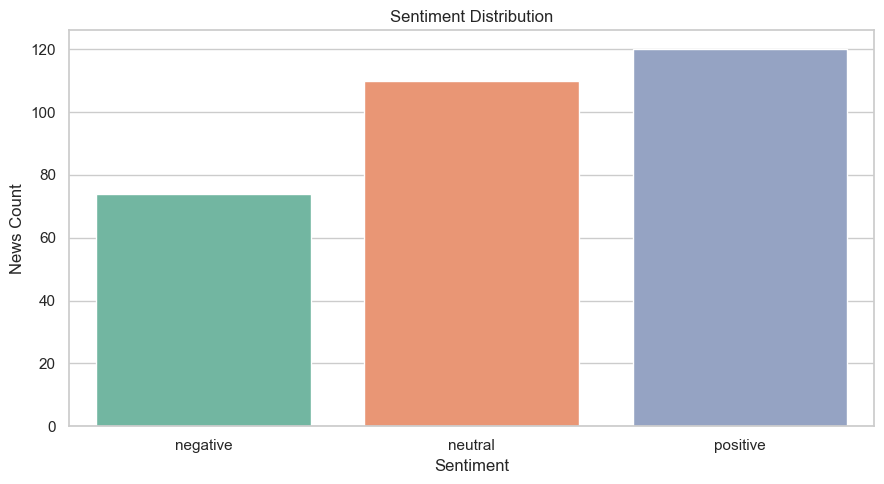

In [6]:
fig, ax = plt.subplots()
sns.barplot(data=sentiment_counts, x="sentiment", y="count", order=SENTIMENT_ORDER, ax=ax, palette="Set2", hue="sentiment", legend=False)
ax.set_title("Sentiment Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("News Count")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sentiment_distribution.png", dpi=160)
plt.show()


In [7]:
sentiment_by_news_type = (
    analysis_df.groupby(["news_type", "sentiment"], dropna=False)
    .size()
    .reset_index(name="count")
)
sentiment_by_news_type["ratio_within_news_type"] = sentiment_by_news_type["count"] / sentiment_by_news_type.groupby("news_type")["count"].transform("sum")
sentiment_by_news_type


,news_type,sentiment,count,ratio_within_news_type
0,industry,negative,5,0.121951
1,industry,neutral,24,0.585366
2,industry,positive,12,0.292683
3,market,negative,51,0.269841
4,market,neutral,69,0.365079
5,market,positive,69,0.365079
6,stock,negative,18,0.243243
7,stock,neutral,17,0.229730
8,stock,positive,39,0.527027


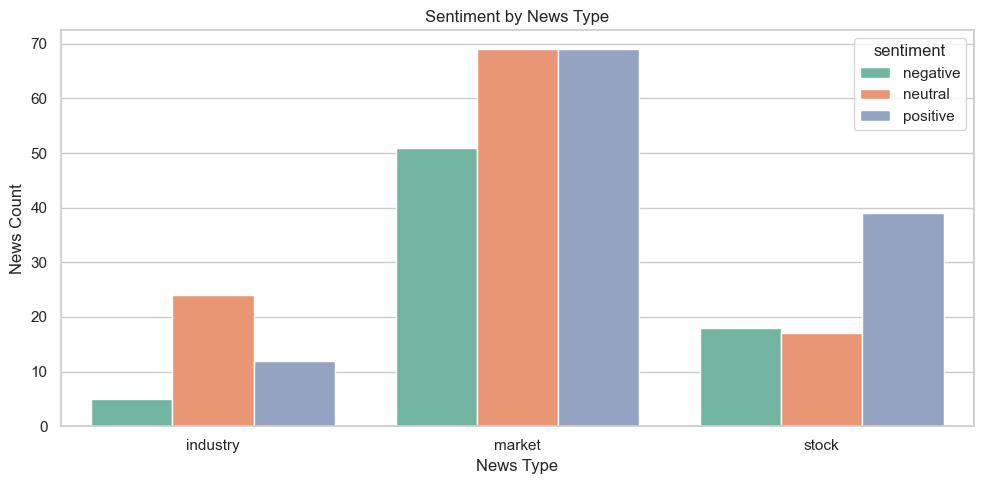

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=sentiment_by_news_type,
    x="news_type",
    y="count",
    hue="sentiment",
    hue_order=SENTIMENT_ORDER,
    palette="Set2",
    ax=ax,
)
ax.set_title("Sentiment by News Type")
ax.set_xlabel("News Type")
ax.set_ylabel("News Count")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sentiment_by_news_type.png", dpi=160)
plt.show()


## Sentiment Score and Future Returns

The correlations below use only rows where the relevant future return is non-null.


In [9]:
correlation_rows = []
for col in RETURN_COLUMNS:
    subset = analysis_df[["sentiment_score", col]].dropna()
    correlation_rows.append({
        "return_horizon": col,
        "sample_size": len(subset),
        "pearson_corr": subset["sentiment_score"].corr(subset[col], method="pearson") if len(subset) >= 2 else pd.NA,
        "spearman_corr": subset["sentiment_score"].corr(subset[col], method="spearman") if len(subset) >= 2 else pd.NA,
    })
correlation_summary = pd.DataFrame(correlation_rows)
correlation_summary.to_csv(TABLE_DIR / "correlation_summary.csv", index=False, encoding="utf-8-sig")
correlation_summary


,return_horizon,sample_size,pearson_corr,spearman_corr
0,future_return_1d,304,0.074962,0.142018
1,future_return_3d,304,0.079548,0.043149
2,future_return_5d,231,-0.040349,-0.080622


In [10]:
sentiment_return_summary = (
    analysis_df.groupby("sentiment", dropna=False)[RETURN_COLUMNS]
    .agg(["count", "mean", "median"])
)
sentiment_return_summary.columns = [f"{return_col}_{stat}" for return_col, stat in sentiment_return_summary.columns]
sentiment_return_summary = sentiment_return_summary.reset_index()
sentiment_return_summary.to_csv(TABLE_DIR / "sentiment_return_summary.csv", index=False, encoding="utf-8-sig")
sentiment_return_summary


,sentiment,future_return_1d_count,future_return_1d_mean,future_return_1d_median,future_return_3d_count,future_return_3d_mean,future_return_3d_median,future_return_5d_count,future_return_5d_mean,future_return_5d_median
0,negative,74,-0.000096,-0.013307,74,0.017793,0.010011,41,0.034415,0.023784
1,neutral,110,0.003969,-0.002755,110,0.016929,0.010011,87,0.021484,-0.002611
2,positive,120,0.005137,0.000000,120,0.025208,0.015385,103,0.023514,-0.002611


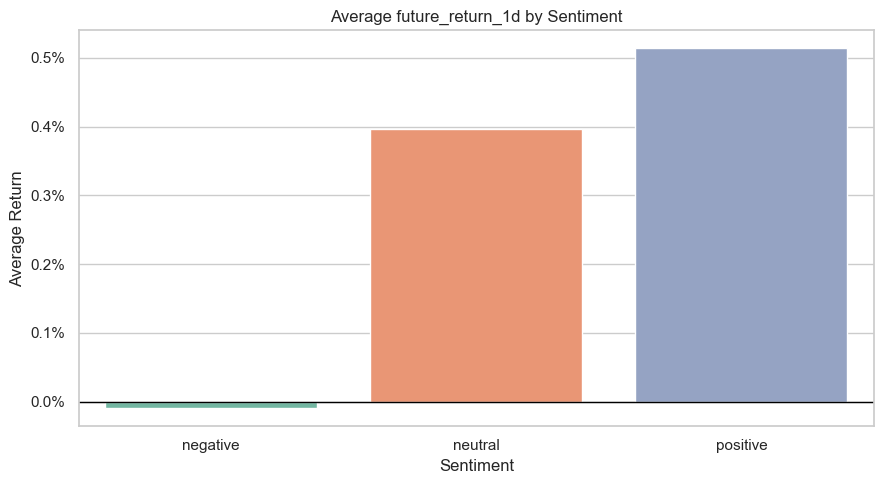

,sentiment,mean,median,count
0,negative,-0.000096,-0.013307,74
1,neutral,0.003969,-0.002755,110
2,positive,0.005137,0.000000,120


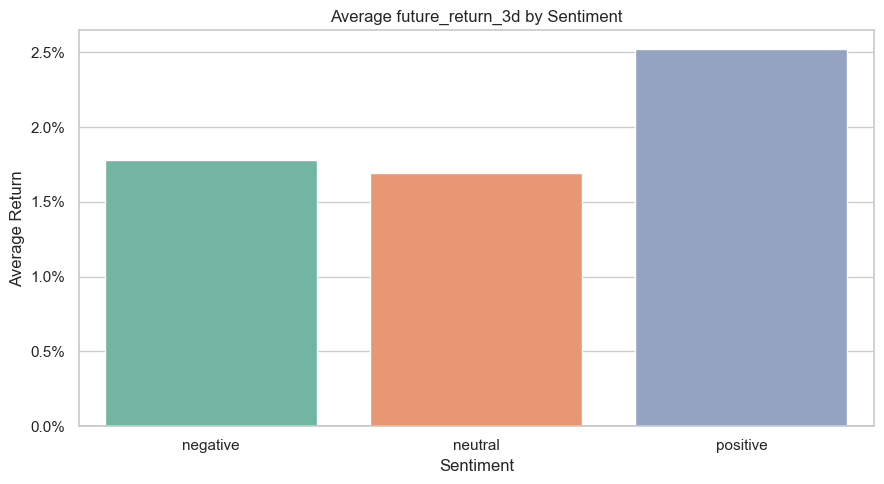

,sentiment,mean,median,count
0,negative,0.017793,0.010011,74
1,neutral,0.016929,0.010011,110
2,positive,0.025208,0.015385,120


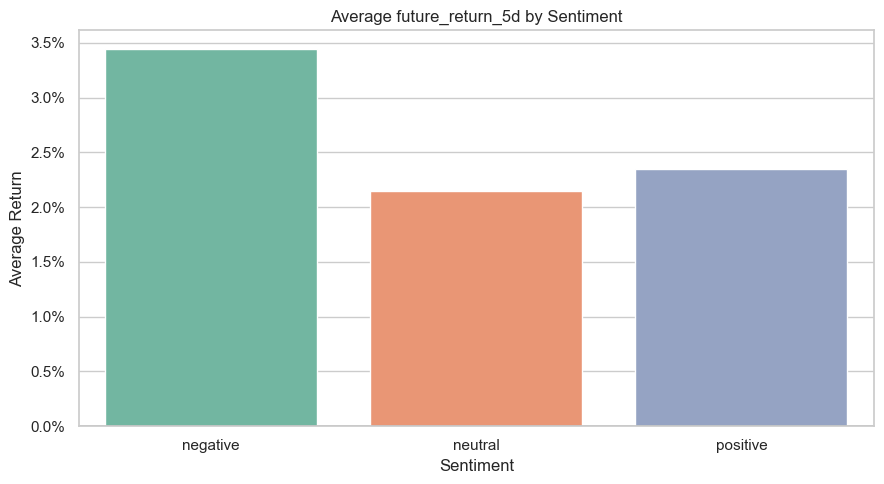

,sentiment,mean,median,count
0,negative,0.034415,0.023784,41
1,neutral,0.021484,-0.002611,87
2,positive,0.023514,-0.002611,103


In [11]:
def plot_return_by_sentiment(return_col: str, filename: str) -> None:
    summary = (
        analysis_df.groupby("sentiment", dropna=False)[return_col]
        .agg(mean="mean", median="median", count="count")
        .reindex(SENTIMENT_ORDER)
        .reset_index()
    )
    fig, ax = plt.subplots()
    sns.barplot(data=summary, x="sentiment", y="mean", order=SENTIMENT_ORDER, ax=ax, palette="Set2", hue="sentiment", legend=False)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Average {return_col} by Sentiment")
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Average Return")
    ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=160)
    plt.show()
    display(summary)

plot_return_by_sentiment("future_return_1d", "return_by_sentiment_1d.png")
plot_return_by_sentiment("future_return_3d", "return_by_sentiment_3d.png")
plot_return_by_sentiment("future_return_5d", "return_by_sentiment_5d.png")


## Return Analysis by News Type

Market and stock rows are the primary analytical groups. Industry rows are listed for visibility, but they should be treated as exploratory unless target normalization and sample construction are reviewed further.


In [12]:
news_type_return_summary = (
    analysis_df.groupby("news_type", dropna=False)[RETURN_COLUMNS]
    .agg(["count", "mean", "median"])
)
news_type_return_summary.columns = [f"{return_col}_{stat}" for return_col, stat in news_type_return_summary.columns]
news_type_return_summary = news_type_return_summary.reset_index()
news_type_return_summary.to_csv(TABLE_DIR / "news_type_return_summary.csv", index=False, encoding="utf-8-sig")
news_type_return_summary


,news_type,future_return_1d_count,future_return_1d_mean,future_return_1d_median,future_return_3d_count,future_return_3d_mean,future_return_3d_median,future_return_5d_count,future_return_5d_mean,future_return_5d_median
0,industry,41,0.003220,-0.008658,41,0.013608,-0.004464,34,0.018922,-0.013333
1,market,189,0.002892,-0.001031,189,0.018049,0.012010,145,0.019309,0.023784
2,stock,74,0.004962,-0.010989,74,0.030199,-0.004464,52,0.043440,-0.010917


In [13]:
for news_type in ["market", "stock", "industry"]:
    subset = analysis_df[analysis_df["news_type"] == news_type]
    display(Markdown(f"### {news_type} news"))
    display(
        subset.groupby("sentiment", dropna=False)[RETURN_COLUMNS]
        .agg(["count", "mean", "median"])
    )


### market news

future_return_1d                     future_return_3d            \
                     count      mean    median            count      mean   
sentiment                                                                   
negative                51  0.001367 -0.007165               51  0.020319   
neutral                 69  0.002863 -0.001031               69  0.017863   
positive                69  0.004049  0.000000               69  0.016556   

                    future_return_5d                      
             median            count      mean    median  
sentiment                                                 
negative   0.010011               29  0.034111  0.024313  
neutral    0.012010               53  0.022016  0.023784  
positive   0.012010               63  0.010219 -0.002611

### stock news

future_return_1d                     future_return_3d            \
                     count      mean    median            count      mean   
sentiment                                                                   
negative                18 -0.007431 -0.015625               18  0.013671   
neutral                 17  0.001471 -0.010989               17  0.030114   
positive                39  0.012204 -0.008658               39  0.037864   

                    future_return_5d                      
             median            count      mean    median  
sentiment                                                 
negative  -0.004464                8  0.049682 -0.004347  
neutral    0.015385               13  0.029176 -0.010917  
positive  -0.004464               31  0.047812 -0.010917

### industry news

future_return_1d                     future_return_3d            \
                     count      mean    median            count      mean   
sentiment                                                                   
negative                 5  0.011394 -0.008658                5  0.006862   
neutral                 24  0.008917 -0.007926               24  0.004903   
positive                12 -0.011579 -0.010989               12  0.033830   

                    future_return_5d                      
             median            count      mean    median  
sentiment                                                 
negative  -0.004464                4  0.006092 -0.015325  
neutral   -0.006667               21  0.015380 -0.013333  
positive   0.017195                9  0.032888 -0.010917

## Saved Outputs


In [14]:
print("Figures:")
for name in [
    "sentiment_distribution.png",
    "sentiment_by_news_type.png",
    "return_by_sentiment_1d.png",
    "return_by_sentiment_3d.png",
    "return_by_sentiment_5d.png",
]:
    path = FIGURE_DIR / name
    print(f"- {path} ({path.exists()})")

print()
print("Tables:")
for name in ["sentiment_return_summary.csv", "news_type_return_summary.csv", "correlation_summary.csv"]:
    path = TABLE_DIR / name
    print(f"- {path} ({path.exists()})")


Figures:
- C:\python_data_analysis_final\outputs\figures\sentiment_distribution.png (True)
- C:\python_data_analysis_final\outputs\figures\sentiment_by_news_type.png (True)
- C:\python_data_analysis_final\outputs\figures\return_by_sentiment_1d.png (True)
- C:\python_data_analysis_final\outputs\figures\return_by_sentiment_3d.png (True)
- C:\python_data_analysis_final\outputs\figures\return_by_sentiment_5d.png (True)

Tables:
- C:\python_data_analysis_final\outputs\tables\sentiment_return_summary.csv (True)
- C:\python_data_analysis_final\outputs\tables\news_type_return_summary.csv (True)
- C:\python_data_analysis_final\outputs\tables\correlation_summary.csv (True)


## Preliminary Observations

The following text is generated from the current dataset. Treat it as a research note, not an investment recommendation.


In [15]:
def fmt_pct(value):
    if pd.isna(value):
        return "n/a"
    return f"{value:.2%}"

observations = []
observations.append(f"The aligned sample contains {len(analysis_df):,} news rows. 1-day and 3-day future returns are fully populated; 5-day returns are available for {analysis_df['future_return_5d'].notna().sum():,} rows.")

if not correlation_summary.empty:
    strongest = correlation_summary.dropna(subset=["pearson_corr"]).copy()
    if not strongest.empty:
        strongest["abs_corr"] = strongest["pearson_corr"].abs()
        row = strongest.sort_values("abs_corr", ascending=False).iloc[0]
        observations.append(f"The largest absolute Pearson correlation between sentiment_score and future returns is {row['pearson_corr']:.4f} for {row['return_horizon']} with n={int(row['sample_size'])}.")

summary_lookup = sentiment_return_summary.set_index("sentiment")
for col in RETURN_COLUMNS:
    mean_col = f"{col}_mean"
    if mean_col in summary_lookup.columns and {"positive", "negative"}.issubset(summary_lookup.index):
        pos = summary_lookup.loc["positive", mean_col]
        neg = summary_lookup.loc["negative", mean_col]
        observations.append(f"For {col}, positive-sentiment rows average {fmt_pct(pos)} while negative-sentiment rows average {fmt_pct(neg)}.")

if "news_type" in news_type_return_summary.columns:
    primary = news_type_return_summary[news_type_return_summary["news_type"].isin(["market", "stock"])]
    if not primary.empty:
        observations.append("Market and stock news now have enough aligned observations for initial notebook analysis; industry rows remain useful for diagnostics but should be interpreted cautiously.")

observations.append("These observations describe this sample only. They do not establish a stable trading signal or investment advice.")

for item in observations:
    display(Markdown(f"- {item}"))


- The aligned sample contains 304 news rows. 1-day and 3-day future returns are fully populated; 5-day returns are available for 231 rows.

- The largest absolute Pearson correlation between sentiment_score and future returns is 0.0795 for future_return_3d with n=304.

- For future_return_1d, positive-sentiment rows average 0.51% while negative-sentiment rows average -0.01%.

- For future_return_3d, positive-sentiment rows average 2.52% while negative-sentiment rows average 1.78%.

- For future_return_5d, positive-sentiment rows average 2.35% while negative-sentiment rows average 3.44%.

- Market and stock news now have enough aligned observations for initial notebook analysis; industry rows remain useful for diagnostics but should be interpreted cautiously.

- These observations describe this sample only. They do not establish a stable trading signal or investment advice.